<a href="https://colab.research.google.com/github/viniciuscristall-spec/CP2-SERS/blob/main/Checkpoint_SERS_ANEEL_PETROLINA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Avaliação — APIs de energia renovável e aprendizado de máquina

Consulte duas APIs públicas, organize os dados e resolva **duas tarefas**: classificar a fonte de empreendimentos da ANEEL e estimar a radiação solar em Petrolina (PE). Em **cada tarefa**, treine e compare **três algoritmos diferentes**. Este notebook fornece a consulta às APIs e os arquivos de dados; **você implementará a análise e os modelos**.

**Entrega:** um único link para um repositório público no GitHub com notebook executável, arquivos de dados, README e resultados. As instruções completas estão ao final e no enunciado separado.

André Debiazzi - RM569062

Kaique Silva - RM572718

Vinicius Cristal - RM572049

## O que é recebido da API?

Uma requisição HTTP `GET` pede dados a uma URL. Os parâmetros identificam o recurso, o período e as variáveis. A resposta é **JSON**: um objeto com chaves e valores. Nas duas consultas desta avaliação, o acesso público **não exige login, token ou chave de API**. Se outra API exigir credenciais, não as publique no repositório.

Este código usa somente `json`, `urllib` e `csv`, bibliotecas que vêm com Python. `csv` serve apenas para exportar os dados recebidos; os imports para análise, tabelas, gráficos e ML são parte da sua implementação.

In [ ]:
import json
import urllib.parse
import urllib.request
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
# --- imports adicionais da Tarefa 2 (regressão) ---
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

A função a seguir monta a URL, abre a conexão, verifica o status HTTP e converte o JSON. Se houver falha na rede ou na API, exibe uma mensagem de erro.

In [ ]:
def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=30) as resposta:
            return json.load(resposta)
    except Exception as erro:
        raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro

# Tarefa 1 — Classificação (ANEEL)

**Pergunta:** a partir da potência e da localização de um empreendimento, é possível classificar sua fonte como **Solar, Eólica ou Hidráulica**?

A fonte é uma **categoria**: o problema é de classificação. O conjunto [SIGA da ANEEL](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel) registra empreendimentos em várias fases. Usamos `UFV` (solar fotovoltaica), `EOL` (eólica) e três categorias hidráulicas: `UHE`, `PCH`, `CGH`. Estas três últimas formarão uma única classe, *Hidráulica*. A tarefa trata da **categoria do cadastro**, não da quantidade de energia gerada.

### Atributos originais da resposta

| Campo da API | Significado | Uso na tarefa |
|---|---|---|
| `SigTipoGeracao` | Sigla do tipo de geração (`UFV`, `EOL`, `UHE`, `PCH`, `CGH`) | Origina o alvo `fonte`; **não entra em X** |
| `MdaPotenciaOutorgadaKw` | Potência outorgada do empreendimento, em quilowatts (kW) | Entrada `potencia_kw`; potência nominal autorizada, não energia produzida |
| `NumCoordNEmpreendimento` | Latitude aproximada do empreendimento, em graus decimais | Entrada `latitude` |
| `NumCoordEEmpreendimento` | Longitude aproximada do empreendimento, em graus decimais | Entrada `longitude` |
| `CodCEG`, `NomEmpreendimento` e campos de combustível | Código, nome e descrição associados ao empreendimento e à fonte | **Não usar como entradas**: podem revelar a classe |

A resposta CKAN contém `success` e `result`; dentro de `result`, `records` são as linhas, `fields` descrevem as colunas e `total` indica o total encontrado para o filtro. O CSV final terá **três atributos numéricos e a classe**. Quantidades consultadas têm limite por tipo e não representam a participação de cada fonte na matriz brasileira.

### 1. Consultar a ANEEL

O recurso SIGA é acessado pela API pública CKAN/DataStore. `resource_id` aponta para o conjunto; `filters` seleciona uma sigla; `limit` limita o retorno de cada pedido. Não há etapa de autenticação para esta consulta pública.

In [ ]:
URL_ANEEL = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"
ID_RECURSO = "11ec447d-698d-4ab8-977f-b424d5deee6a"
SIGLAS = ["UFV", "EOL", "UHE", "PCH", "CGH"]
print("API ANEEL: consulta pública, sem token")

API ANEEL: consulta pública, sem token


In [ ]:
registros_aneel = []
for sigla in SIGLAS:
    parametros = {
        "resource_id": ID_RECURSO,
        "filters": json.dumps({"SigTipoGeracao": sigla}),
        "limit": 1200,
    }
    resposta = consultar_api(URL_ANEEL, parametros)
    if not resposta.get("success"):
        raise ValueError(f"Consulta da ANEEL falhou para {sigla}")
    linhas = resposta["result"]["records"]
    print(f"{sigla}: {len(linhas)} linhas recebidas")
    registros_aneel.extend(linhas)
print("Total de linhas recebidas:", len(registros_aneel))

UFV: 1200 linhas recebidas
EOL: 1200 linhas recebidas
UHE: 221 linhas recebidas
PCH: 537 linhas recebidas
CGH: 718 linhas recebidas
Total de linhas recebidas: 3876


### 2. Gerar o CSV para a tarefa

A API pode fornecer números como texto, inclusive com vírgula decimal. O tratamento abaixo converte esses valores, descarta linhas sem potência ou coordenadas e transforma as siglas em três classes. Cada linha do arquivo final representa **um empreendimento**. Confira a quantidade de exemplos por classe durante sua análise; se necessário, discuta o desequilíbrio entre classes.

In [ ]:
def numero(valor):
    texto = str(valor).strip()
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    try:
        return float(texto)
    except ValueError:
        return None

fontes = {"UFV": "Solar", "EOL": "Eólica", "UHE": "Hidráulica",
          "PCH": "Hidráulica", "CGH": "Hidráulica"}
linhas_classificacao = []
for registro in registros_aneel:
    potencia = numero(registro.get("MdaPotenciaOutorgadaKw"))
    latitude = numero(registro.get("NumCoordNEmpreendimento"))
    longitude = numero(registro.get("NumCoordEEmpreendimento"))
    fonte = fontes.get(registro.get("SigTipoGeracao"))
    if fonte and all(valor is not None for valor in (potencia, latitude, longitude)):
        linhas_classificacao.append([potencia, latitude, longitude, fonte])
if len(linhas_classificacao) < 90:
    raise ValueError("Poucos registros válidos: confira a resposta da ANEEL")
print("Linhas válidas:", len(linhas_classificacao))
print("Primeiro exemplo:", linhas_classificacao[0])

Linhas válidas: 3876
Primeiro exemplo: [20.48, -10.44277778, -64.15194444, 'Solar']


In [ ]:
with open("aneel_classificacao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["potencia_kw", "latitude", "longitude", "fonte"])
    escritor.writerows(linhas_classificacao)
print("Salvo: aneel_classificacao_orange.csv")

Salvo: aneel_classificacao_orange.csv


### O que você deve fazer — classificação

1. Carregue o CSV, confira os tipos das colunas, as contagens por classe, valores ausentes e distribuições relevantes. Explique `X` (três entradas) e `y` (`fonte`).
2. Faça uma divisão **estratificada** de treino/teste, por exemplo 80%/20%, com semente fixa. Ajustes de escala aprendidos dos dados devem ser feitos **somente com o treino**.
3. Escolha, justifique e treine **três classificadores diferentes** usando a mesma divisão. Eles **não estão importados nem implementados** neste notebook.
4. Compare Accuracy, Precision, Recall e F1. Declare o tipo de média usado nas métricas por classe (por exemplo, `macro`) e apresente a matriz de confusão.
5. Explique qual modelo escolheria, quais classes ele mais confunde e por que potência/localização podem não bastar para uma aplicação real. Não use `SigTipoGeracao`, nomes, CEG ou descrições da fonte como entradas.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico(s) ou matriz de confusão e interpretação escrita.

In [ ]:
df_aneel = pd.read_csv('aneel_classificacao_orange.csv')
df_aneel.head()

,potencia_kw,latitude,longitude,fonte
0,20.48,-10.442778,-64.151944,Solar
1,5000.00,-6.003889,-40.274722,Solar
2,12.26,-23.557778,-46.734000,Solar
3,3.00,-23.558889,-46.735000,Solar
4,1.70,-23.493819,-46.845000,Solar


In [ ]:
df_aneel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3876 entries, 0 to 3875
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   potencia_kw  3876 non-null   float64
 1   latitude     3876 non-null   float64
 2   longitude    3876 non-null   float64
 3   fonte        3876 non-null   object 
dtypes: float64(3), object(1)
memory usage: 121.3+ KB


In [ ]:
df_aneel.isnull().sum()

,0
potencia_kw,0
latitude,0
longitude,0
fonte,0


In [ ]:
display(df_aneel['fonte'].value_counts())

,count
fonte,
Hidráulica,1476
Solar,1200
Eólica,1200


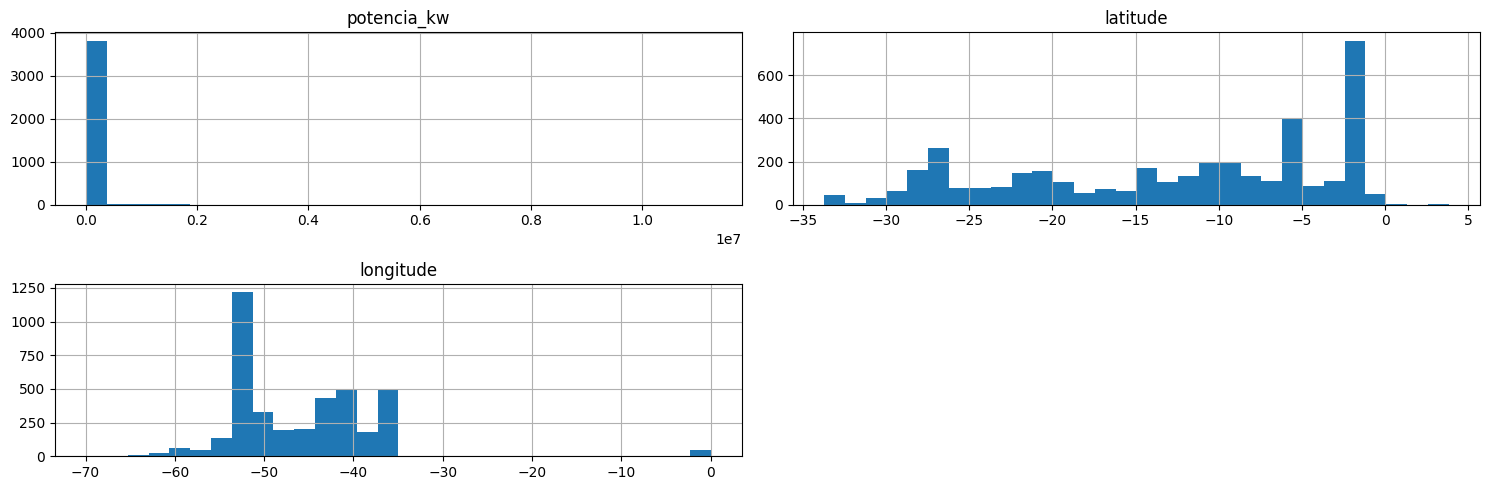

In [ ]:
df_aneel[['potencia_kw', 'latitude', 'longitude']].hist(bins=30, figsize=(15, 5))
plt.tight_layout()
plt.show()

*   **`X` (features)**: `potencia_kw`, `latitude`, `longitude`.
*   **`y` (target)**: `fonte`.

In [ ]:
X = df_aneel[['potencia_kw', 'latitude', 'longitude']]
y = df_aneel['fonte']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

escala = StandardScaler()
X_train_escala = escala.fit_transform(X_train)
X_test_escala = escala.transform(X_test)

print(f"Formato X_train_escala: {X_train_escala.shape}")
print(f"Formato X_test_escala: {X_test_escala.shape}")
print(f"Formato y_train: {y_train.shape}")
print(f"Formato y_test: {y_test.shape}")

print("\nDistribuição de classes na divisão:")
print("Treino:\n", y_train.value_counts(normalize=True))
print("Teste:\n", y_test.value_counts(normalize=True))

Formato X_train_escala: (3100, 3)
Formato X_test_escala: (776, 3)
Formato y_train: (3100,)
Formato y_test: (776,)

Distribuição de classes na divisão:
Treino:
 fonte
Hidráulica    0.380645
Solar         0.309677
Eólica        0.309677
Name: proportion, dtype: float64
Teste:
 fonte
Hidráulica    0.381443
Solar         0.309278
Eólica        0.309278
Name: proportion, dtype: float64


###Treinando os modelos

In [ ]:
modelo_knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))
modelo_knn.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('kneighborsclassifier', KNeighborsClassifier())])

In [ ]:
modelo_arvore = DecisionTreeClassifier(max_depth=6, random_state=42)
modelo_arvore.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6, random_state=42)

In [ ]:
modelo_floresta = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
modelo_floresta.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

###Avaliando os modelos

In [ ]:
modelos_class = {"KNN": modelo_knn, "Árvore": modelo_arvore,
                 "Floresta": modelo_floresta}
resultados_class = []
for nome, modelo in modelos_class.items():
    previsao = modelo.predict(X_test)
    resultados_class.append({
        "Modelo": nome,
        "Accuracy": accuracy_score(y_test, previsao),
        "Precision macro": precision_score(y_test, previsao, average="macro", zero_division=0),
        "Recall macro": recall_score(y_test, previsao, average="macro", zero_division=0),
        "F1 macro": f1_score(y_test, previsao, average="macro", zero_division=0),
    })
tabela_class = pd.DataFrame(resultados_class)
display(tabela_class.round(3))

,Modelo,Accuracy,Precision macro,Recall macro,F1 macro
0,KNN,0.965,0.966,0.964,0.965
1,Árvore,0.912,0.910,0.908,0.908
2,Floresta,0.976,0.977,0.974,0.975


### Matrizes de Confusão

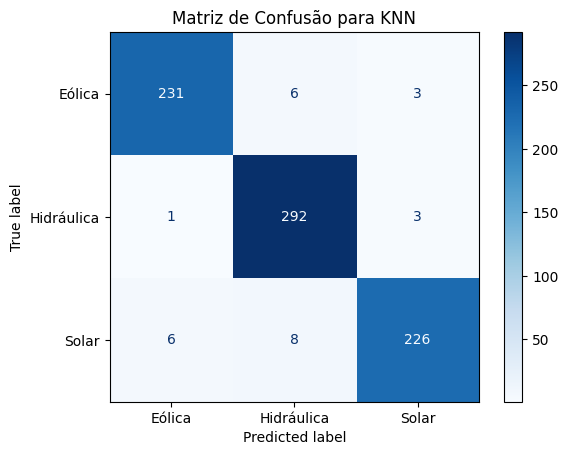

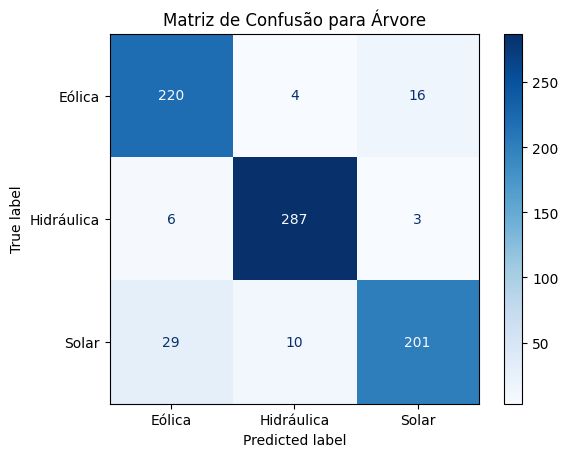

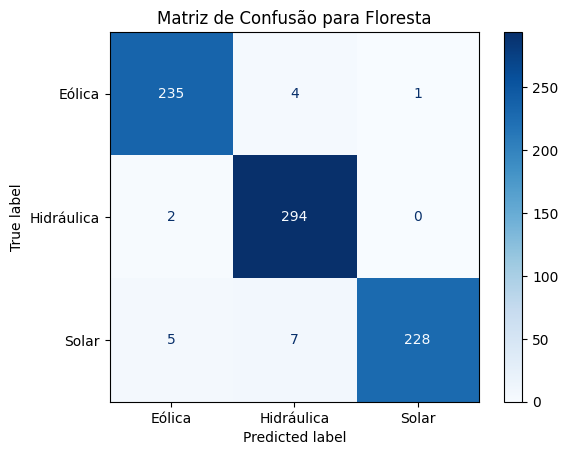

In [ ]:
for nome, modelo in modelos_class.items():
    previsao = modelo.predict(X_test)
    cm = confusion_matrix(y_test, previsao, labels=modelo.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Matriz de Confusão para {nome}')
    plt.show()

### Análise dos Resultados

Com base na tabela de métricas e nas matrizes de confusão, podemos observar:

*   **Random Forest** apresentou o melhor desempenho em todas as métricas, o que significa que é o modelo mais robusto e com melhor capacidade de classificação.
*   **KNN** apresentou um desempenho intermediário, com métricas próximas às da Random Forest, o que sugere que a distância entre os pontos no espaço de características é um bom indicador da classe da fonte de energia.
*   A **Árvore de Decisão** teve o pior desempenho entre os três, o que pode indicar que um modelo mais simples pode não compreender completamente a complexidade dos dados.

Ao observar as matrizes de confusão nota-se que o modelo **Random Forest** comete menos erros. No entanto, é possível notar que, mesmo nos modelos de melhor desempenho, pode haver alguma confusão entre as classes, especialmente entre **Hidráulica** e **Solar** ou **Hidráulica** e **Eólica**. Por exemplo, pode-se notar que alguns empreendimentos que são 'Hidráulica' são classificados como 'Solar' ou vice-versa. Isto acontece, pois estas fontes são as mais comuns no dataset e podem apresentar sobreposições em termos de potência que dificultam a distinção.

Apesar de potência e localização sejam características importantes e mostrem-se eficazes na classificação com os modelos treinados, elas podem não ser suficientes para uma aplicação real completa por várias razões:

1.  **Características Geográficas Específicas**: Apenas latitude e longitude podem não capturar nuances importantes. Por exemplo, a elevação do terreno ou a topografia podem ser cruciais para identificar usinas hidrelétricas, mas não são explicitamente representadas por latitude/longitude de forma granular.
2.  **Variabilidade de Potência**: A potência de uma usina não é um indicador exclusivo de sua fonte. Usinas de pequeno porte podem ter potências semelhantes, dificultando a distinção apenas por esse atributo.
3.  **Tecnologia e Regulamentação**: Informações sobre a tecnologia específica de geração, ano de construção, status regulatório ou tipo de licença podem fornecer pistas adicionais importantes para a classificação, especialmente para distinguir entre fontes com características de potência e localização sobrepostas.
4.  **Crescimento e Evolução das Fontes**: Novas tecnologias e métodos de instalação podem levar a perfis de potência e localização que não se encaixam nos padrões históricos, tornando os modelos baseados apenas nessas duas características menos robustos a longo prazo.
5.  **Dados Faltantes ou Inconsistentes**: Em um cenário real, dados de localização ou potência podem estar ausentes ou ser imprecisos, impactando a performance de modelos que dependem exclusivamente deles.

Para uma aplicação real, seria ideal incorporar mais características contextuais e específicas do empreendimento, além de considerar abordagens que possam lidar com a evolução dos dados ao longo do tempo.

# Tarefa 2 — Regressão (Open-Meteo)

**Pergunta:** dadas as condições meteorológicas e a hora local em Petrolina (PE), qual é a radiação solar horizontal média naquela hora? A resposta é um **número**, então o problema é de regressão.

A API histórica do [Open-Meteo](https://open-meteo.com/en/docs/historical-weather-api) devolve dados horários para coordenadas e período escolhidos. Usamos **1º de abril a 30 de junho de 2025**, em horário local. São dados históricos estimados por modelos/reanálise, não leituras de um sensor particular. **Radiação em W/m² não equivale à energia em kWh nem à geração de um painel.**

### Parâmetros da requisição

| Parâmetro | Valor nesta avaliação | Significado |
|---|---|---|
| `latitude`, `longitude` | `-9.39`, `-40.50` | Coordenadas aproximadas de Petrolina (PE) |
| `start_date`, `end_date` | `2025-04-01`, `2025-06-30` | Período histórico consultado, inclusive as datas extremas |
| `timezone` | `America/Recife` | Faz `time` representar a hora local |
| `hourly` | Lista das cinco variáveis abaixo | Solicita valores horários em JSON |

### Atributos do conjunto de dados

| Campo da API → CSV | Significado e unidade | Uso na tarefa |
|---|---|---|
| `time` → `data_hora` | Data e hora local de cada registro | Ordenar e separar por tempo; não é entrada em X |
| `temperature_2m` → `temperatura_c` | Temperatura do ar a 2 m, em °C | Entrada |
| `relative_humidity_2m` → `umidade_pct` | Umidade relativa a 2 m, em % | Entrada |
| `cloud_cover` → `nuvens_pct` | Cobertura total de nuvens, em % | Entrada |
| `wind_speed_10m` → `vento_kmh` | Velocidade do vento a 10 m, em km/h | Entrada |
| `time` → `hora` | Hora local extraída da data, de 7 a 17 nesta amostra | Entrada |
| `shortwave_radiation` → `radiacao_w_m2` | Radiação solar global horizontal média da hora anterior, em W/m² | Alvo numérico `y`; **não entra em X** |

A resposta inclui `hourly` (listas dos valores, alinhadas por índice), `hourly_units` (unidades) e metadados da localização. Cada linha do CSV final representa **uma hora entre 7h e 17h**; esse recorte reduz o domínio de horas noturnas, mas não remove a importância da hora para a previsão.

### 3. Consultar o histórico meteorológico

A chamada usa GET, sem cadastro ou chave para esta consulta pública de uso educacional. Se `hourly` faltar, verifique datas e parâmetros.

In [ ]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
parametros_meteo = {
    "latitude": -9.39,
    "longitude": -40.50,
    "start_date": "2025-04-01",
    "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join(["temperature_2m", "relative_humidity_2m",
                         "cloud_cover", "wind_speed_10m", "shortwave_radiation"]),
}
print("Open-Meteo: consulta pública, sem token")

Open-Meteo: consulta pública, sem token


In [ ]:
resposta_meteo = consultar_api(URL_METEO, parametros_meteo)
if "hourly" not in resposta_meteo:
    raise ValueError("Resposta sem a seção hourly")
horas_api = resposta_meteo["hourly"]
print("Campos recebidos:", list(horas_api))
print("Unidades informadas pela API:", resposta_meteo.get("hourly_units", {}))
print("Quantidade de horários:", len(horas_api["time"]))

Campos recebidos: ['time', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation']
Unidades informadas pela API: {'time': 'iso8601', 'temperature_2m': '°C', 'relative_humidity_2m': '%', 'cloud_cover': '%', 'wind_speed_10m': 'km/h', 'shortwave_radiation': 'W/m²'}
Quantidade de horários: 2184


### 4. Gerar o CSV horário

As listas de `hourly` são alinhadas: o índice 0 de cada variável se refere ao índice 0 de `time`. Percorremos esses índices, mantemos as horas de 7h a 17h e descartamos linhas com valores ausentes. A data permanece ordenada para facilitar uma avaliação temporal.

In [ ]:
nomes_api = ["temperature_2m", "relative_humidity_2m", "cloud_cover",
             "wind_speed_10m", "shortwave_radiation"]
linhas_regressao = []
for indice, data_hora in enumerate(horas_api["time"]):
    hora = int(data_hora[11:13])
    valores = [horas_api[nome][indice] for nome in nomes_api]
    if 7 <= hora <= 17 and all(valor is not None for valor in valores):
        linhas_regressao.append([data_hora, *valores[:4], hora, valores[4]])
if len(linhas_regressao) < 100:
    raise ValueError("Poucos horários válidos: confira a resposta do Open-Meteo")
print("Horas válidas:", len(linhas_regressao))
print("Primeiro exemplo:", linhas_regressao[0])

Horas válidas: 1001
Primeiro exemplo: ['2025-04-01T07:00', 25.3, 74, 100, 17.7, 7, 116.0]


In [ ]:
with open("meteo_regressao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["data_hora", "temperatura_c", "umidade_pct",
                       "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"])
    escritor.writerows(linhas_regressao)
print("Salvo: meteo_regressao_orange.csv")

Salvo: meteo_regressao_orange.csv


### O que você deve fazer — regressão

1. Carregue o CSV, explique as colunas, examine valores ausentes e apresente ao menos uma visualização. Defina `X` (cinco entradas) e `y` (`radiacao_w_m2`).
2. Mantenha as linhas em ordem de `data_hora`: use aproximadamente **80% das primeiras horas para treino** e as 20% finais para teste. Evite embaralhar as horas. Ajuste transformações apenas com o treino.
3. Escolha, justifique e treine **três algoritmos de regressão diferentes** com a mesma divisão. Os imports e a implementação são sua responsabilidade.
4. Compare **MAE** (W/m²), **MSE** ((W/m²)²) e **R²**; faça um gráfico de valores reais × previstos de pelo menos um modelo.
5. Interprete os erros, discuta o peso da hora e explique por que essa estimativa da radiação **não prevê automaticamente a energia produzida** por um sistema fotovoltaico.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico e interpretação escrita. Nenhum valor de `radiacao_w_m2` deve ser usado para criar uma entrada do mesmo registro.

In [ ]:
# Configuração da Tarefa 2 (semente fixa, tema dos gráficos e formato numérico)
SEMENTE = 42          # semente fixa para reprodutibilidade
np.random.seed(SEMENTE)
sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

## 3. Carregamento e exploração dos dados

| Coluna | Significado | Papel |
|---|---|---|
| `data_hora` | Data e hora local do registro | Ordenação/divisão temporal — **não é entrada** |
| `temperatura_c` | Temperatura do ar a 2 m (°C) | Entrada |
| `umidade_pct` | Umidade relativa a 2 m (%) | Entrada |
| `nuvens_pct` | Cobertura total de nuvens (%) | Entrada |
| `vento_kmh` | Velocidade do vento a 10 m (km/h) | Entrada |
| `hora` | Hora local (7 a 17) | Entrada |
| `radiacao_w_m2` | Radiação solar global horizontal média da hora anterior (W/m²) | **Alvo (`y`)** |

In [ ]:
dfpetrolina = pd.read_csv("meteo_regressao_orange.csv", parse_dates=["data_hora"])
display(dfpetrolina.head())
print()
dfpetrolina.info()

,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
0,2025-04-01 07:00:00,25.300,74,100,17.700,7,116.000
1,2025-04-01 08:00:00,26.500,66,100,18.100,8,269.000
2,2025-04-01 09:00:00,28.400,55,97,18.000,9,529.000
3,2025-04-01 10:00:00,30.800,44,21,18.400,10,797.000
4,2025-04-01 11:00:00,32.700,36,26,20.100,11,880.000



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   data_hora      1001 non-null   datetime64[ns]
 1   temperatura_c  1001 non-null   float64       
 2   umidade_pct    1001 non-null   int64         
 3   nuvens_pct     1001 non-null   int64         
 4   vento_kmh      1001 non-null   float64       
 5   hora           1001 non-null   int64         
 6   radiacao_w_m2  1001 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(3)
memory usage: 54.9 KB


In [ ]:
print("Valores ausentes por coluna:")
display(dfpetrolina.isnull().sum().to_frame("ausentes"))
print("Período:", dfpetrolina["data_hora"].min(), "→", dfpetrolina["data_hora"].max())
print("Linhas:", len(dfpetrolina), "| Dias:", dfpetrolina["data_hora"].dt.date.nunique(), "| Horas por dia:", sorted(dfpetrolina["hora"].unique()))
display(dfpetrolina.describe().T)

Valores ausentes por coluna:


,ausentes
data_hora,0
temperatura_c,0
umidade_pct,0
nuvens_pct,0
vento_kmh,0
hora,0
radiacao_w_m2,0


Período: 2025-04-01 07:00:00 → 2025-06-30 17:00:00
Linhas: 1001 | Dias: 91 | Horas por dia: [np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17)]


,count,mean,min,25%,50%,75%,max,std
data_hora,1001,2025-05-16 11:59:59.999999744,2025-04-01 07:00:00,2025-04-23 15:00:00,2025-05-16 12:00:00,2025-06-08 09:00:00,2025-06-30 17:00:00,NaN
temperatura_c,"1,001.000",28.886,19.500,26.300,29.100,31.700,36.100,3.657
umidade_pct,"1,001.000",50.544,21.000,38.000,49.000,61.000,95.000,15.914
nuvens_pct,"1,001.000",55.109,0.000,19.000,54.000,98.000,100.000,37.851
vento_kmh,"1,001.000",15.465,2.300,12.200,15.400,19.000,30.100,4.924
hora,"1,001.000",12.000,7.000,9.000,12.000,15.000,17.000,3.164
radiacao_w_m2,"1,001.000",472.854,13.000,250.000,466.000,696.000,"1,002.000",256.369


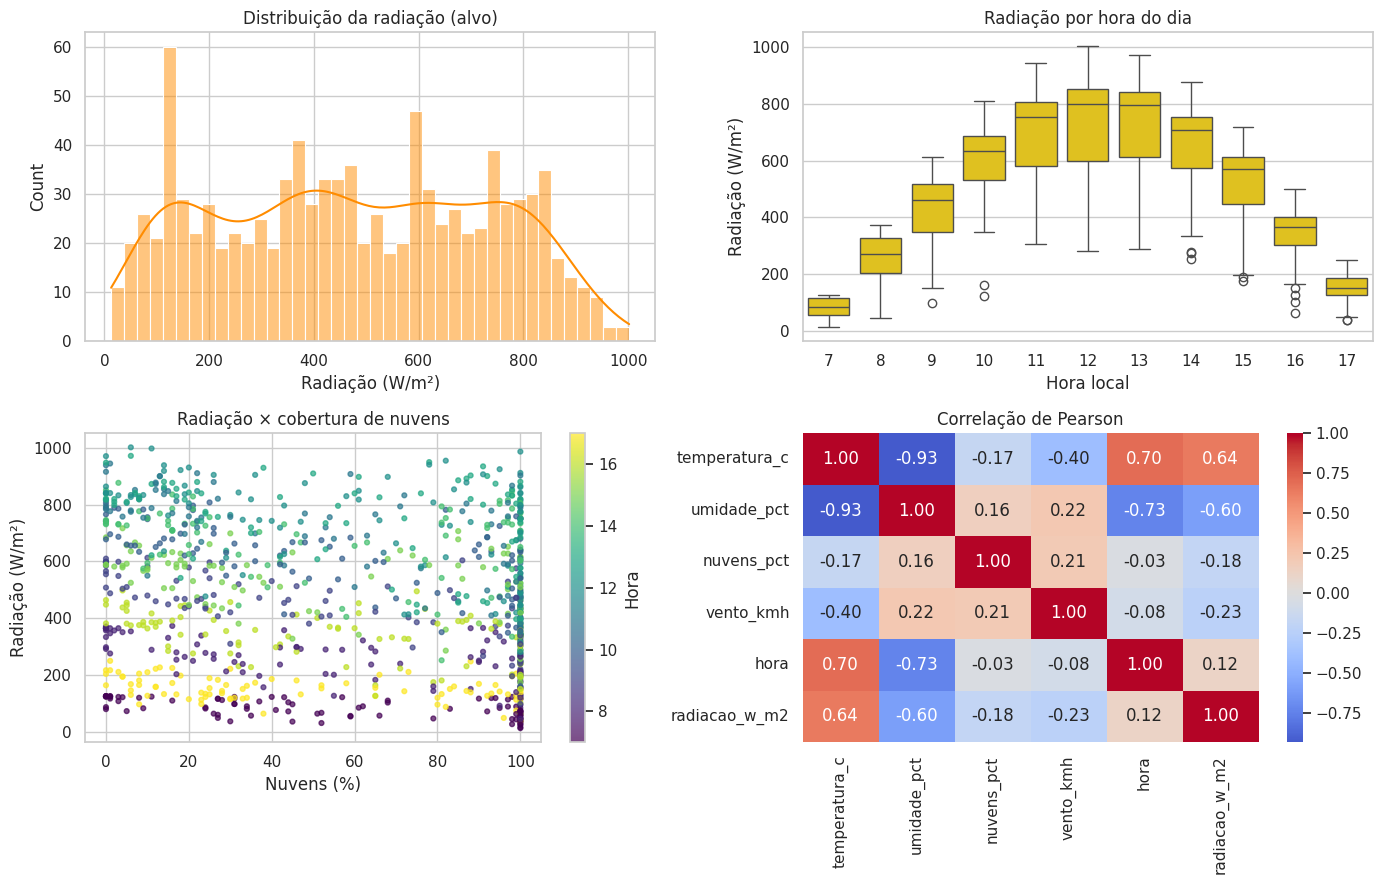

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# (a) Distribuição do alvo
sns.histplot(dfpetrolina["radiacao_w_m2"], bins=40, kde=True, ax=axes[0, 0], color="darkorange")
axes[0, 0].set(title="Distribuição da radiação (alvo)", xlabel="Radiação (W/m²)")

# (b) Radiação por hora do dia
sns.boxplot(data=dfpetrolina, x="hora", y="radiacao_w_m2", ax=axes[0, 1], color="gold")
axes[0, 1].set(title="Radiação por hora do dia", xlabel="Hora local", ylabel="Radiação (W/m²)")

# (c) Radiação x nuvens, colorida pela hora
sc = axes[1, 0].scatter(dfpetrolina["nuvens_pct"], dfpetrolina["radiacao_w_m2"], c=dfpetrolina["hora"], cmap="viridis", s=12, alpha=0.7)
axes[1, 0].set(title="Radiação × cobertura de nuvens", xlabel="Nuvens (%)", ylabel="Radiação (W/m²)")
fig.colorbar(sc, ax=axes[1, 0], label="Hora")

# (d) Correlações
sns.heatmap(dfpetrolina.drop(columns="data_hora").corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1, 1])
axes[1, 1].set_title("Correlação de Pearson")

plt.tight_layout()
plt.savefig("fig_exploracao.png", dpi=120)
plt.show()

**Leitura dos gráficos:** a radiação tem forma de "sino" ao longo do dia (menor em 7h e 17h, máxima perto do meio-dia solar), então a `hora` tem relação **não linear** com o alvo. A cobertura de nuvens tende a reduzir a radiação para uma mesma hora. Como a relação com `hora` não é uma reta, espera-se que modelos capazes de captar não linearidade e interações (árvores) se saiam melhor que a regressão linear.

## 4. Definição de `X` e `y`

* **`X` (5 entradas):** `temperatura_c`, `umidade_pct`, `nuvens_pct`, `vento_kmh`, `hora`.
* **`y` (alvo):** `radiacao_w_m2`.
* `data_hora` **não** entra em `X` (serve só para ordenar/dividir) e nenhuma transformação de `radiacao_w_m2` é usada como entrada, evitando vazamento de dados.

In [ ]:
COLUNAS_X = ["temperatura_c", "umidade_pct", "nuvens_pct", "vento_kmh", "hora"]
COLUNA_Y = "radiacao_w_m2"

# Ordem cronológica (sem embaralhar)
dfpetrolina = dfpetrolina.sort_values("data_hora").reset_index(drop=True)

X = dfpetrolina[COLUNAS_X]
y = dfpetrolina[COLUNA_Y]

assert COLUNA_Y not in X.columns and "data_hora" not in X.columns  # checagem anti-vazamento
print("X:", X.shape, "| y:", y.shape)
print("Entradas:", list(X.columns))

X: (1001, 5) | y: (1001,)
Entradas: ['temperatura_c', 'umidade_pct', 'nuvens_pct', 'vento_kmh', 'hora']


## 5. Divisão temporal treino/teste (80% / 20%)

Como os dados são uma série no tempo, **não embaralhamos**: as primeiras 80% das horas formam o treino e as 20% finais, o teste. Isso simula o uso real (treinar com o passado e prever o futuro) e evita que o modelo "veja" horas vizinhas do teste durante o treino. A padronização (`StandardScaler`) é ajustada **apenas no treino**, dentro de um `Pipeline`.

Treino: 800 linhas | 2025-04-01 07:00:00 → 2025-06-12 14:00:00
Teste : 201 linhas | 2025-06-12 15:00:00 → 2025-06-30 17:00:00


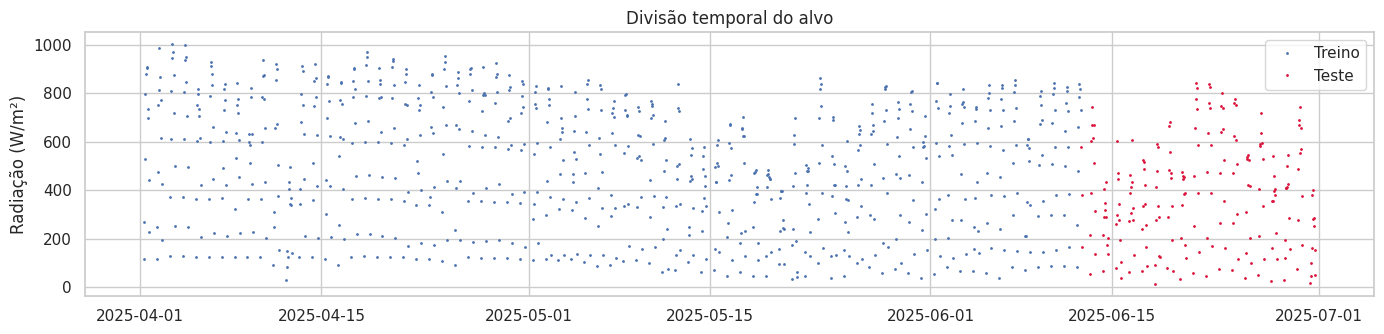

In [ ]:
corte = int(len(dfpetrolina) * 0.8)
X2_train, X2_test = X.iloc[:corte], X.iloc[corte:]
y2_train, y2_test = y.iloc[:corte], y.iloc[corte:]
datas_test = dfpetrolina["data_hora"].iloc[corte:]

print(f"Treino: {len(X2_train)} linhas | {dfpetrolina['data_hora'].iloc[0]} → {dfpetrolina['data_hora'].iloc[corte-1]}")
print(f"Teste : {len(X2_test)} linhas | {dfpetrolina['data_hora'].iloc[corte]} → {dfpetrolina['data_hora'].iloc[-1]}")

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.plot(dfpetrolina["data_hora"].iloc[:corte], y2_train, ".", ms=2, label="Treino")
ax.plot(datas_test, y2_test, ".", ms=2, color="crimson", label="Teste")
ax.set(title="Divisão temporal do alvo", ylabel="Radiação (W/m²)")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Escolha dos três algoritmos

| Algoritmo | Família | Por que foi escolhido |
|---|---|---|
| **Regressão Linear** | Modelo linear | *Baseline* simples e interpretável. Usa `StandardScaler` ajustado no treino. Serve de referência: se os outros não o superarem, a complexidade não compensa. |
| **Random Forest** | Ensemble por *bagging* de árvores | Capta relações não lineares e interações (ex.: efeito das nuvens que depende da hora), é robusto a ruído e exige pouca preparação (não precisa de escala). |
| **Gradient Boosting** | Ensemble por *boosting* de árvores | Constrói árvores em sequência, corrigindo os erros das anteriores; costuma ter alta precisão em dados tabulares. |

Os hiperparâmetros são valores razoáveis fixos, com `random_state=42`, **definidos sem olhar o conjunto de teste**. Todos os modelos usam exatamente a mesma divisão.

In [ ]:
modelos = {
    "Regressão Linear": make_pipeline(StandardScaler(), LinearRegression()),
    "Random Forest": RandomForestRegressor(n_estimators=300, min_samples_leaf=3,
                                           random_state=SEMENTE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                                   max_depth=3, random_state=SEMENTE),
}

previsoes = {}
for nome, modelo in modelos.items():
    modelo.fit(X2_train, y2_train)
    previsoes[nome] = modelo.predict(X2_test)
    print(f"{nome}: treinado")

Regressão Linear: treinado
Random Forest: treinado
Gradient Boosting: treinado


## 7. Comparação: MAE, MSE e R²

Todas as métricas são calculadas no **mesmo conjunto de teste** (últimas 20% das horas). MAE em W/m², MSE em (W/m²)², R² adimensional. Incluímos também o RMSE (W/m²) apenas como apoio, por estar na mesma unidade do alvo.

In [ ]:
def avaliar(nome, y2_real, y2_prev):
    mse = mean_squared_error(y2_real, y2_prev)
    return {"Algoritmo": nome,
            "MAE (W/m²)": mean_absolute_error(y2_real, y2_prev),
            "MSE ((W/m²)²)": mse,
            "RMSE (W/m²)": np.sqrt(mse),
            "R²": r2_score(y2_real, y2_prev)}

tabela = pd.DataFrame([avaliar(n, y2_test, p) for n, p in previsoes.items()]).set_index("Algoritmo")
display(tabela)
tabela.to_csv("resultados_regressao.csv")

print("\nPrevisões negativas (fisicamente impossíveis) por modelo:")
for nome, prev in previsoes.items():
    print(f"  {nome}: {(prev < 0).sum()} de {len(prev)}")

,MAE (W/m²),MSE ((W/m²)²),RMSE (W/m²),R²
Algoritmo,,,,
Regressão Linear,145.205,"30,034.201",173.304,0.360
Random Forest,69.277,"7,859.748",88.655,0.832
Gradient Boosting,64.945,"7,233.587",85.050,0.846



Previsões negativas (fisicamente impossíveis) por modelo:
  Regressão Linear: 19 de 201
  Random Forest: 0 de 201
  Gradient Boosting: 0 de 201


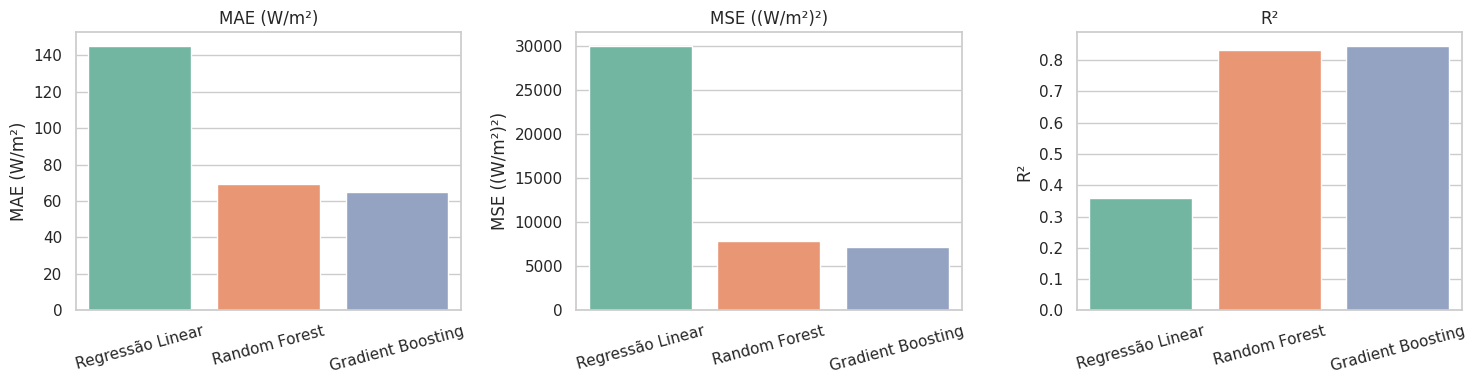

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metrica in zip(axes, ["MAE (W/m²)", "MSE ((W/m²)²)", "R²"]):
    sns.barplot(x=tabela.index, y=tabela[metrica], ax=ax, hue=tabela.index, palette="Set2", legend=False)
    ax.set_title(metrica); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig("fig_metricas_regressao.png", dpi=120)
plt.show()

## 8. Valores reais × previstos

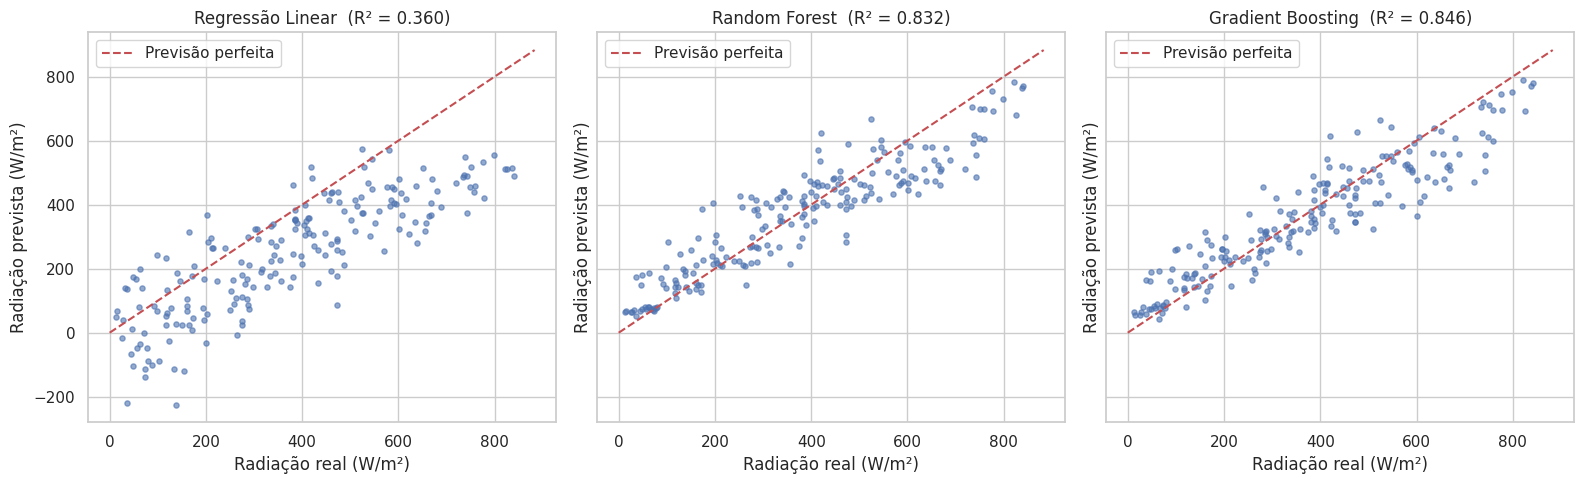

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)
limite = max(y2_test.max(), max(p.max() for p in previsoes.values())) * 1.05
for ax, (nome, prev) in zip(axes, previsoes.items()):
    ax.scatter(y2_test, prev, s=14, alpha=0.6)
    ax.plot([0, limite], [0, limite], "r--", label="Previsão perfeita")
    ax.set(title=f"{nome}  (R² = {tabela.loc[nome, 'R²']:.3f})",
           xlabel="Radiação real (W/m²)", ylabel="Radiação prevista (W/m²)")
    ax.legend()
plt.tight_layout()
plt.savefig("fig_real_vs_previsto.png", dpi=120)
plt.show()

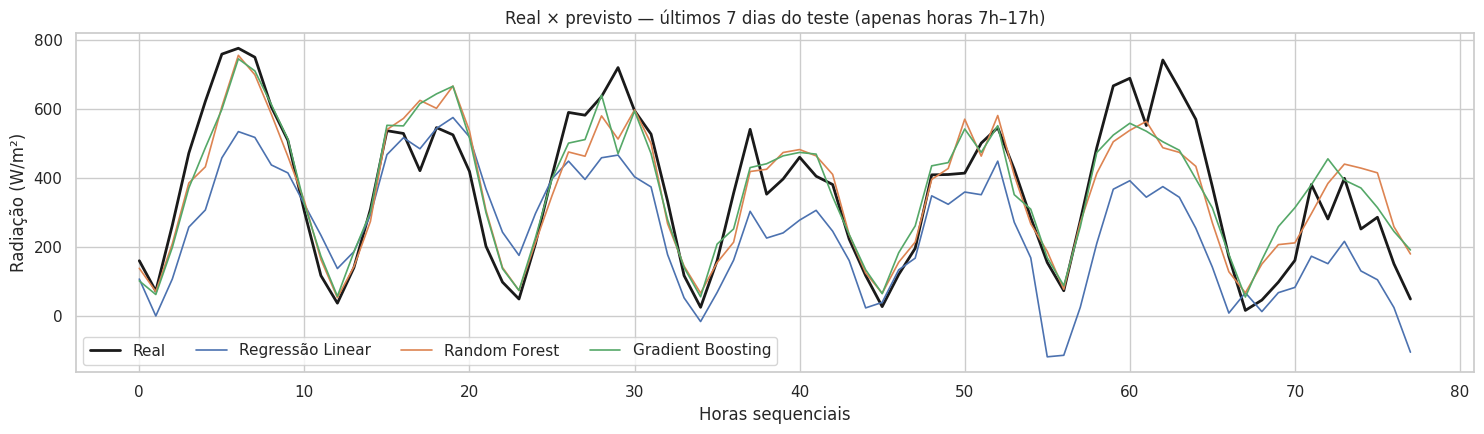

In [ ]:
# Série temporal dos últimos 7 dias do teste
ultimos = datas_test >= (datas_test.max() - pd.Timedelta(days=7))
fig, ax = plt.subplots(figsize=(15, 4.5))
idx = np.arange(ultimos.sum())          # eixo sequencial (só horas diurnas)
ax.plot(idx, y2_test[ultimos.values].values, "k-", lw=2, label="Real")
for nome, prev in previsoes.items():
    ax.plot(idx, prev[ultimos.values], lw=1.2, label=nome)
ax.set(title="Real × previsto — últimos 7 dias do teste (apenas horas 7h–17h)",
       xlabel="Horas sequenciais", ylabel="Radiação (W/m²)")
ax.legend(ncol=4)
plt.tight_layout()
plt.savefig("fig_serie_teste.png", dpi=120)
plt.show()

## 9. Análise dos erros e o papel da hora do dia

,Regressão Linear,Random Forest,Gradient Boosting
hora,,,
7,99.602,21.492,24.677
8,107.074,33.396,50.861
9,125.832,68.238,69.458
10,181.692,94.728,100.318
11,178.331,86.947,80.972
12,163.596,76.326,75.559
13,188.609,88.576,80.667
14,160.315,91.215,69.590
15,132.542,86.244,58.147


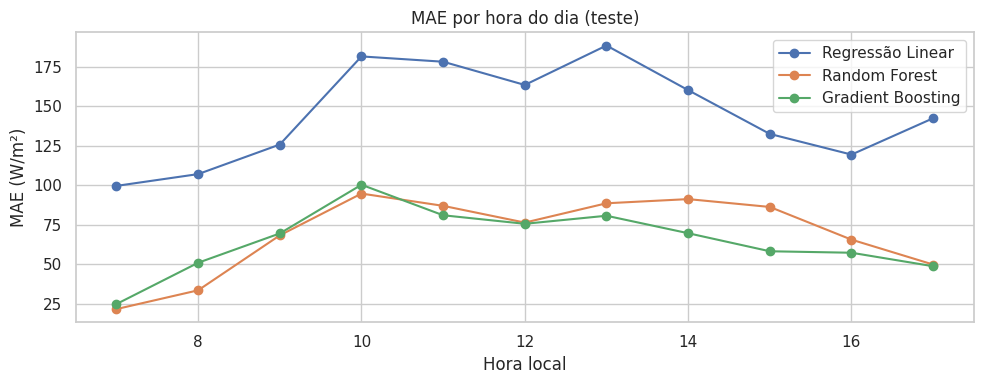

In [ ]:
analise = dfpetrolina.iloc[corte:].copy()
for nome, prev in previsoes.items():
    analise[nome] = np.abs(y2_test.values - prev)

mae_por_hora = analise.groupby("hora")[list(previsoes)].mean()
display(mae_por_hora)

ax = mae_por_hora.plot(marker="o", figsize=(10, 4))
ax.set(title="MAE por hora do dia (teste)", xlabel="Hora local", ylabel="MAE (W/m²)")
plt.tight_layout()
plt.savefig("fig_mae_por_hora.png", dpi=120)
plt.show()

In [ ]:
# Importância da hora e das demais variáveis (Random Forest, no teste)
rf = modelos["Random Forest"]
perm = permutation_importance(rf, X2_test, y2_test, n_repeats=10, random_state=SEMENTE,
                              scoring="neg_mean_absolute_error")
imp = pd.DataFrame({"Importância interna (RF)": rf.feature_importances_,
                    "Aumento do MAE ao embaralhar (W/m²)": perm.importances_mean},
                   index=COLUNAS_X).sort_values("Aumento do MAE ao embaralhar (W/m²)", ascending=False)
display(imp)

# Ablação: o que acontece sem a variável 'hora'?
sem_hora = [c for c in COLUNAS_X if c != "hora"]
rf_sem = RandomForestRegressor(n_estimators=300, min_samples_leaf=3, random_state=SEMENTE, n_jobs=-1)
rf_sem.fit(X2_train[sem_hora], y2_train)
p_sem = rf_sem.predict(X2_test[sem_hora])
comparacao = pd.DataFrame([avaliar("Random Forest COM hora", y2_test, previsoes["Random Forest"]),
                           avaliar("Random Forest SEM hora", y2_test, p_sem)]).set_index("Algoritmo")
display(comparacao)

,Importância interna (RF),Aumento do MAE ao embaralhar (W/m²)
hora,0.492,94.115
temperatura_c,0.297,50.936
umidade_pct,0.181,28.203
nuvens_pct,0.018,11.155
vento_kmh,0.012,1.422


,MAE (W/m²),MSE ((W/m²)²),RMSE (W/m²),R²
Algoritmo,,,,
Random Forest COM hora,69.277,"7,859.748",88.655,0.832
Random Forest SEM hora,131.103,"30,895.481",175.771,0.341


In [ ]:
# Resumo numérico gerado automaticamente a partir dos resultados desta execução
melhor = tabela["MAE (W/m²)"].idxmin()
pior = tabela["MAE (W/m²)"].idxmax()
hora_pior = mae_por_hora[melhor].idxmax()
media_teste = y2_test.mean()

print(f"Melhor modelo (menor MAE): {melhor} — MAE = {tabela.loc[melhor, 'MAE (W/m²)']:.1f} W/m², "
      f"R² = {tabela.loc[melhor, 'R²']:.3f}")
print(f"Pior modelo (maior MAE): {pior} — MAE = {tabela.loc[pior, 'MAE (W/m²)']:.1f} W/m², "
      f"R² = {tabela.loc[pior, 'R²']:.3f}")
print(f"Radiação média no teste: {media_teste:.1f} W/m² → MAE do melhor modelo ≈ "
      f"{100*tabela.loc[melhor, 'MAE (W/m²)']/media_teste:.1f}% da média")
print(f"Hora com maior erro para o {melhor}: {hora_pior}h (MAE = {mae_por_hora[melhor].max():.1f} W/m²)")
mae_com = comparacao.iloc[0]["MAE (W/m²)"]; mae_sem = comparacao.iloc[1]["MAE (W/m²)"]
print(f"Retirar a 'hora' do Random Forest muda o MAE de {mae_com:.1f} para {mae_sem:.1f} W/m² "
      f"({100*(mae_sem-mae_com)/mae_com:+.1f}%)")

Melhor modelo (menor MAE): Gradient Boosting — MAE = 64.9 W/m², R² = 0.846
Pior modelo (maior MAE): Regressão Linear — MAE = 145.2 W/m², R² = 0.360
Radiação média no teste: 373.4 W/m² → MAE do melhor modelo ≈ 17.4% da média
Hora com maior erro para o Gradient Boosting: 10h (MAE = 100.3 W/m²)
Retirar a 'hora' do Random Forest muda o MAE de 69.3 para 131.1 W/m² (+89.2%)


## 10. Interpretação dos resultados

> Os valores exatos (MAE, MSE, R², hora de maior erro) estão na tabela da seção 7 e no resumo automático da seção 9. Abaixo estão as conclusões conceituais; **confira se elas condizem com os números da sua execução**.

**Desempenho dos modelos.** A Regressão Linear é o *baseline*: ela só consegue ajustar retas, mas a radiação ao longo do dia tem formato de sino em função da `hora`, então tende a errar mais e pode até prever valores negativos (contagem na seção 7). Random Forest e Gradient Boosting captam não linearidades e interações (por exemplo, o efeito das nuvens depende da hora) e, em geral, reduzem MAE e MSE e aumentam o R². O MSE penaliza mais os erros grandes (é elevado ao quadrado), então é sensível a horas de meio-dia com nuvens passageiras, em que a radiação real muda bruscamente.

**Onde erram mais.** Em geral, os erros absolutos tendem a ser maiores nas horas centrais, quando a radiação é alta e varia mais; nas bordas (7h e 17h) a radiação é baixa e o Sol está rasante, o que também pode gerar erros relativos altos. Veja o gráfico de MAE por hora (seção 9) para saber em quais horas *o seu* resultado erra mais. A cobertura de nuvens total é uma informação agregada: não diz *qual camada* nem *onde* estão as nuvens, e por isso não explica toda a variação da radiação.

**Peso da hora do dia.** A `hora` é um substituto da posição do Sol (ângulo de elevação): sem ela, o modelo não sabe se a mesma cobertura de nuvens acontece de manhã cedo ou ao meio-dia. A importância por permutação e o experimento de ablação (seção 9) quantificam quanto o erro piora sem essa variável.

**Limitações da avaliação.** O teste corresponde ao final de junho (aproximadamente as últimas semanas do período), com condições que podem diferir das de abril/maio. Além disso, são apenas 3 meses de dados de um único local; os dados são estimados por modelo/reanálise, não medidos por sensor. Isso limita a generalização para outras estações do ano ou locais. Um ano ou mais de dados, validação cruzada temporal (`TimeSeriesSplit`) e ajuste de hiperparâmetros seriam melhorias naturais.

**Por que estimar radiação não é prever a geração elétrica.** A radiação global horizontal (W/m²) é uma *potência por área* recebida numa superfície plana; a energia de um sistema fotovoltaico (kWh) depende de muito mais:

* **Integração no tempo:** kWh = potência × tempo; W/m² de uma hora não é energia sem multiplicar pela área e pela duração.
* **Inclinação e orientação do painel:** o painel raramente é horizontal; a radiação no plano do painel é diferente da horizontal.
* **Eficiência do módulo e da temperatura:** a eficiência cai quando o painel esquenta (a temperatura da célula é maior que a do ar).
* **Perdas do sistema:** inversor, cabeamento, sujeira (soiling), sombreamento, degradação e indisponibilidade.
* **Radiação direta × difusa:** os painéis respondem de formas diferentes a cada componente, e a global horizontal mistura ambas.
* **Rede e operação:** limitações de injeção (curtailment) e manutenção também afetam a geração real.

Portanto, o modelo aqui serve como estimativa do **recurso solar** disponível, e não como previsão da **energia elétrica gerada**.

# Entrega pelo GitHub

Envie **apenas o link do repositório público**. Organize-o com:

- `README.md` contendo objetivo, fontes e período dos dados, instruções para executar o notebook e resumo dos resultados;
- notebook `.ipynb` com a consulta às APIs, sua análise, os **três classificadores e os três regressores**, todos os imports necessários adicionados por você e conclusões em Markdown;
- os dois CSVs gerados (ou instruções completas e testadas para reproduzi-los) e eventuais figuras utilizadas.

Verifique se o notebook roda **na ordem das células** a partir de um ambiente limpo. Não inclua senhas, tokens ou arquivos sem relação com a avaliação. A banca deve conseguir encontrar as seis comparações e as respostas às duas tarefas sem procurar uma agulha no palheiro.

### Fontes

- [ANEEL — SIGA](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel)
- [ANEEL — recurso e campos usados](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel/resource/11ec447d-698d-4ab8-977f-b424d5deee6a)
- [Open-Meteo — histórico e unidades](https://open-meteo.com/en/docs/historical-weather-api)